In [4]:
import os
#os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=4"
#os.environ["JAX_PLATFORM_NAME"] = "cpu"

import jax
from jax.sharding import NamedSharding , PartitionSpec as P
from jax.experimental.shard_map import shard_map
from functools import partial
from jax import lax
import jax.numpy as jnp

mesh = jax.make_mesh((jax.device_count(),), ('dp',))
sharding = NamedSharding(mesh, P('dp'))


In [ ]:

import itertools
import numpy as np
import jax.numpy as jnp
from scipy.interpolate import interp1d
import logging

logger = logging.getLogger("GRIDDING")


class GridSearch:

    def __init__(self, objective_fn, search_space, batch_size=None):
        """
        Initialize the grid search.

        Args:
            objective_fn: The objective function to be evaluated.
            search_space: A dictionary where keys are parameter names and values are lists of possible values.
            batch_size: The number of combinations to evaluate in each batch. If None, it is determined automatically.
        """
        keys, values = zip(*search_space.items())

        self.param_keys = keys
        self.search_space = search_space
        self.objective_fn = jax.jit(
            objective_fn)  # JIT compile the objective function
        # Create an iterator over all parameter combinations$
        self.combinations = list(itertools.product(*values))
        self.n_combinations = len(self.combinations)

        if self.n_combinations % jax.process_count() != 0:
            raise ValueError(
                f"Number of combinations ({self.n_combinations}) must be evenly divisible "
                f"by the number of processes ({jax.process_count()}).")

        # Automatically determine batch size if None
        if batch_size is None:
            if jax.devices()[0].platform == "cpu":
                logger.warning("""
                Batch size not specified and automatic batch size determination is not supported on CPU.
                Falling back to default batch size of 64.
                """)
                self.batch_size = 2
            else:
                self.batch_size = self._determine_batch_size()
                print(f"Auto-determined maximum batch size: {self.batch_size}")
                if self.batch_size > self.n_combinations:
                    self.batch_size = self.n_combinations
                print(f"Selecting batch size of {self.batch_size}")

    def _measure_memory_usage(self, batch_size):
        """
        Measure memory usage of the objective function for a given batch size.

        Args:
            batch_size: The batch size to test.

        Returns:
            Estimated memory usage in bytes.
        """
        # Create a batch of representative inputs

        if jax.devices()[0].platform == "cpu":
            raise ValueError(
                "Memory measurement is not supported on CPU platform.")

        param_sample = {
            key: np.array([val[0]] * batch_size)
            for key, val in self.search_space.items()
        }

        # Analyze memory usage
        mem_analysis = jax.jit(jax.vmap(self.objective_fn)).lower(
            **param_sample).compile().memory_analysis()
        assert mem_analysis is not None

        return (mem_analysis.argument_size_in_bytes +
                mem_analysis.output_size_in_bytes +
                mem_analysis.temp_size_in_bytes)

    def _determine_batch_size(self):
        """
        Estimate the largest feasible batch size based on device memory constraints.

        Returns:
            The estimated maximum batch size.
        """
        if jax.devices()[0].platform == "cpu":
            raise ValueError(
                "Memory measurement is not supported on CPU platform.")

        memory_stats = jax.devices()[0].memory_stats()
        assert memory_stats is not None

        max_device_memory = memory_stats['bytes_limit'] - memory_stats['bytes_in_use']

        # Measure memory usage for progressively larger batch sizes
        test_batch_sizes = [2, 4, 8, 16, 32]
        memory_usages = []
        for batch_size in test_batch_sizes:
            try:
                memory_usages.append(self._measure_memory_usage(batch_size))
            except Exception as e:
                print(
                    f"Error measuring memory for batch size {batch_size}: {e}")
                break

        # Ensure we have valid data points
        if len(memory_usages) < 2:
            raise ValueError(
                "Not enough data points to interpolate memory usage.")

        # Interpolate to predict the maximum batch size
        interpolator = interp1d(memory_usages,
                                test_batch_sizes[:len(memory_usages)],
                                kind='linear',
                                fill_value="extrapolate")
        max_batch_size = int(interpolator(max_device_memory) * 0.8)
        return max_batch_size

    def _batch_generator(self, indx=0, size=1):
        """Generates batches of parameter combinations."""
        current_slice_combinitions = self.combinations[indx *
                                                       self.n_combinations //
                                                       size:(indx + 1) *
                                                       self.n_combinations //
                                                       size]
        n_batches = len(current_slice_combinitions) // self.batch_size

        for i in range(n_batches):
            yield current_slice_combinitions[i * self.batch_size:(i + 1) *
                                             self.batch_size]

    def run(self):
        """
        Run the grid search.

        Returns:
            A dict of arrays with parameter names and corresponding objective function values, sorted by value.
        """
        # Prepare a list to hold batches of results
        batch_results = {key: [] for key in self.param_keys}
        batch_results["value"] = []

        rank = jax.process_index()
        size = jax.process_count()

        for batch in self._batch_generator(rank, size):
            param_dicts = [
                dict(zip(self.param_keys, combo)) for combo in batch
            ]
            param_arrays = {
                key: jnp.array([d[key] for d in param_dicts])
                for key in self.param_keys
            }

            # Apply the objective function
            values = jax.vmap(lambda **kwargs: self.objective_fn(**kwargs))(
                **param_arrays)

            # Store the results as arrays
            for i, param_dict in enumerate(param_dicts):
                for key in param_dict:
                    batch_results[key].append(param_dict[key])
                batch_results["value"].append(values[i])

        # Stack the results into arrays along the new axis
        stacked_results = {
            key: jnp.stack(value, axis=0)
            for key, value in batch_results.items()
        }

        # Optional: Sort the results based on the "value"
        sorted_results = {
            key: value[stacked_results["value"].argsort()]
            for key, value in stacked_results.items()
        }

        return sorted_results


# Example objective function
def objective_fn(x, y, z, w):
    return (x - 2)**2 + (y - 3)**2 + (z - 4)**2 * (w - 5)**2


# Example search space
search_space = {
    "x": jnp.arange(0, 10),
    "y": jnp.arange(0, 10),
    "z": jnp.arange(0, 10),
    "w": jnp.arange(0, 10),
}

# Run the grid search with automatic batch size determination
grid_search = GridSearch(objective_fn, search_space, batch_size=None)
results = grid_search.run()

for keys, values in results.items():
    print(f"{keys} : {values[0]}")



Auto-determined maximum batch size: 249625753
Selecting batch size of 10000
x : 2
y : 3
z : 0
w : 5
value : 0


: 

In [14]:
results

[]

In [47]:
for arr in jax.live_arrays():
    arr.delete()

In [ ]:
jax.devices()[0].memory_stats()['bytes_in_use']

0

In [53]:
def obj(beta_d , beta_pl , temp_d):
    params = {"beta_dust": beta_d, "beta_pl": beta_pl, "temp_dust": temp_d}

    return negative_log_likelihood(params,
                                nu=nu,
                                N=invN,
                                d=d)


search_space = {
    "beta_d": np.linspace(0.5 , 2.5 , 20),
    "beta_pl": np.linspace(-6.0 , -2.0 , 20),
    "temp_d": np.linspace(10.0 , 30.0 , 20)
}

grid_search = GridSearch(obj, search_space, batch_size=None)

results = grid_search.run()

Auto-determined batch size: 422


In [1]:
%load_ext autoreload
%autoreload 2
import jax
import jax.numpy as jnp

from furax._base.blocks import BlockDiagonalOperator, BlockRowOperator
from furax._base.core import HomothetyOperator, IdentityOperator
from furax.landscapes import StokesPyTree, ValidStokesType , HealpixLandscape
from furax.tree import as_structure
from furax.operators.sed import CMBOperator, DustOperator, SynchrotronOperator
import operator
from math import prod
from itertools import product
from matplotlib import pyplot as plt

In [2]:
nside = 64
npixel = 12 * nside**2
stokes_type: ValidStokesType = 'IQU'
frequency_count = 15

In [50]:
# FGBUSTER IMPORTS
import healpy as hp
import pysm3

from fgbuster import (CMB, Dust, Synchrotron, 
                      basic_comp_sep, MixingMatrix,
                      get_observation, get_instrument)
from fgbuster.visualization import corner_norm

# FURAX IMPORTS
import jax
import jaxopt
import jax.numpy as jnp
from jax import ShapeDtypeStruct

from furax._base.blocks import BlockDiagonalOperator, BlockRowOperator
from furax._base.core import HomothetyOperator, IdentityOperator
from furax.landscapes import StokesPyTree, ValidStokesType, HealpixLandscape
from furax.tree import as_structure
from furax.operators.sed import CMBOperator, DustOperator, SynchrotronOperator , MixingMatrixOperator
import operator
from math import prod
import numpy as np
from functools import partial

import os
import pickle
nside = 32
npixel = nside ** 2 * 12
dust_nu0 = 150.0
synchrotron_nu0 = 20.0
stokes_type: ValidStokesType = 'IQU'
instrument = get_instrument('LiteBIRD')

# Define cache file path
cache_dir = 'freq_maps_cache'
cache_file = os.path.join(cache_dir, f'freq_maps_nside_{nside}.pkl')

# Check if file exists and load if it does; otherwise raise an error with guidance
if os.path.exists(cache_file):
    with open(cache_file, 'rb') as f:
        freq_maps = pickle.load(f)
    print(f"Loaded freq_maps for nside {nside} from cache.")
else:
    raise FileNotFoundError(
        f"Cache file for freq_maps with nside {nside} not found.\n"
        f"Please generate it first by calling `generate_maps({nside})`."
    )

# Check the shape of freq_maps
print("freq_maps shape:", freq_maps.shape)

d = StokesPyTree.from_stokes(I=freq_maps[:,0,:], Q=freq_maps[:,1,:], U=freq_maps[:,2,:])
structure = HealpixLandscape(nside, stokes_type).structure
d.structure

invN = HomothetyOperator(jnp.ones(1), _in_structure=d.structure)
DND = invN(d) @ d

in_structure = HealpixLandscape(nside, stokes_type).structure
best_params = {'temp_dust': 20., 'beta_dust': 1.54, 'beta_pl': -3.0}
nu = instrument['frequency'].values

@jax.jit
def negative_log_prob(params, d):
    cmb = CMBOperator(nu, in_structure=in_structure)
    dust = DustOperator(
        nu,
        frequency0=dust_nu0,
        temperature=params['temp_dust'],
        beta=params['beta_dust'],
        in_structure=in_structure,
    )
    synchrotron = SynchrotronOperator(nu,
                                      frequency0=synchrotron_nu0,
                                      beta_pl=params['beta_pl'],
                                      in_structure=in_structure)

    A =  MixingMatrixOperator(cmb=cmb, dust=dust, synchrotron=synchrotron)

    x = (A.T @ invN)(d)
    l = jax.tree.map(lambda a, b: a @ b, x, (A.T @ invN @ A).I(x))
    summed_log_prob = jax.tree.reduce(operator.add, l)

    return -summed_log_prob 

from furax.comp_sep import spectral_log_likelihood, spectral_cmb_variance, negative_log_likelihood

negative_log_likelihood = partial(negative_log_likelihood , dust_nu0=dust_nu0, synchrotron_nu0=synchrotron_nu0)

L = negative_log_likelihood(best_params,
                            nu=nu,
                            N=invN,
                            d=d)

assert jax.tree.all(
    jax.tree.map(lambda x, y: jnp.isclose(x, y, rtol=1e-5), L,
                 negative_log_prob(best_params, d)))

Loaded freq_maps for nside 32 from cache.
freq_maps shape: (15, 3, 12288)


In [3]:
comp_keys = jax.random.split(jax.random.PRNGKey(0), 3)
stokes_cls = StokesPyTree.class_for(stokes_type)
frequencies = jnp.linspace(10.0, 300, 15)

sky = {
    'cmb': stokes_cls.normal(comp_keys[0], (npixel, )),
    'dust': stokes_cls.normal(comp_keys[1], (npixel, )),
    'synchrotron': stokes_cls.normal(comp_keys[2], (npixel, )),
}

In [4]:
import healpy as hp
import numpy as np 
import kmeans_radec
from kmeans_radec import KMeans, kmeans_sample

def get_regions(mask, n_regions, nside, unassigned=hp.UNSEEN):
    """ Generates `n_regions` regions of roughly equal area
    for a given sky mask `mask`, assuming HEALPix "RING"
    ordering. Returns a HEALPix map where each pixel holds
    the index of the region it is assigned to. Unassigned
    pixels will take the `unassigned` value.
    """
    npix = len(mask)
    hp.npix2nside(npix)
    ipix = np.arange(npix)
    ra, dec = hp.pix2ang(nside, ipix, lonlat=True)
    goodpix = mask > 0
    km = kmeans_sample(np.array([ra[goodpix], dec[goodpix]]).T,
                       n_regions, maxiter=100, tol=1.0e-5,
                       verbose=False)
    map_ids = np.full(npix, unassigned)
    map_ids[ipix[goodpix]] = km.labels
    return map_ids

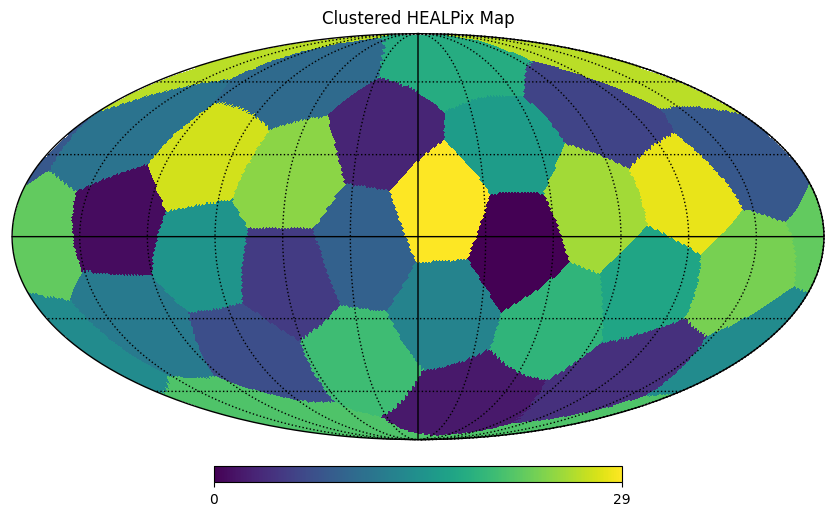

In [4]:
import healpy as hp
import numpy as np
from sklearn.cluster import KMeans

def cluster_healpix_map(input_map, n_clusters):
    """
    Cluster a HEALPix map using the spherical angular coordinates converted to Cartesian coordinates,
    then return a clustered HEALPix map with cluster labels.
    
    Parameters:
        input_map (np.ndarray): HEALPix map data to be clustered.
        n_clusters (int): The number of clusters.
        NSIDE (int): The HEALPix map resolution parameter.
        
    Returns:
        np.ndarray: A HEALPix map with pixel labels corresponding to cluster assignments.
    """
    npix = len(input_map)
    NSIDE = hp.npix2nside(len(input_map))
    # Step 1: Convert the HEALPix pixel indices to spherical coordinates (theta, phi)
    theta, phi = hp.pix2ang(NSIDE, np.arange(npix))

    # Step 2: Convert spherical coordinates (theta, phi) to Cartesian coordinates (x, y, z)
    # (x, y, z) are unit vectors on the unit sphere
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)

    # Step 3: Stack x, y, z to create a 2D array of coordinates
    coordinates = np.vstack([x, y, z]).T  # Shape will be (npix, 3)

    # Step 4: Apply KMeans clustering in 3D Cartesian space
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=0)
    cluster_labels = kmeans.fit_predict(coordinates)

    # Step 5: Map the cluster labels back to the HEALPix map
    clustered_map = np.full(npix, -1, dtype=int)  # Initialize with -1 for undefined regions
    clustered_map[:] = cluster_labels  # Assign cluster labels to pixels
    
    

    return clustered_map

# Example usage
NSIDE = 64  # HEALPix map resolution parameter
input_map = np.random.rand(hp.nside2npix(NSIDE))  # Sample data for clustering
n_clusters = 30  # Number of clusters

# Run the function to create and display the clustered map
clustered_map = cluster_healpix_map(input_map, n_clusters)
# Step 6: Visualize the clustered map
hp.mollview(clustered_map, title="Clustered HEALPix Map")
hp.graticule()


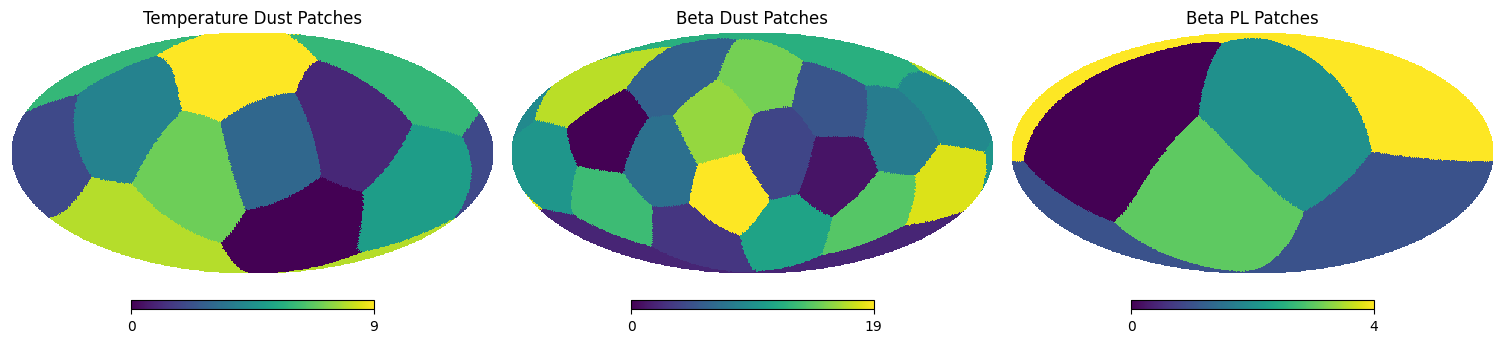

In [5]:
temp_dust_patches_count = 10
beta_dust_patches_count = 20
beta_pl_patches_count = 5

to_cluster_map = sky['dust'].i

temp_dust_patch_indices = cluster_healpix_map(to_cluster_map, temp_dust_patches_count)
beta_dust_patch_indices = cluster_healpix_map(to_cluster_map, beta_dust_patches_count)
beta_pl_patch_indices = cluster_healpix_map(to_cluster_map, beta_pl_patches_count)

# Set up subplots
fig= plt.figure(figsize=(15, 5))
# Plot each map
hp.mollview(temp_dust_patch_indices,title='Temperature Dust Patches', sub=(1, 3, 1))
hp.mollview(beta_dust_patch_indices, title='Beta Dust Patches', sub=(1, 3, 2))
hp.mollview(beta_pl_patch_indices, title='Beta PL Patches', sub=(1, 3, 3))

# Display the plot
plt.show()

In [6]:
dust_nu0 = 150.0
synchrotron_nu0 = 20.0

def make_mixing_matrix_operator(params, patch_indices, in_structure):
    cmb = CMBOperator(frequencies, in_structure=in_structure)
    dust = DustOperator(
        frequencies,
        frequency0=dust_nu0,
        temperature=params['temp_dust'],
        temperature_patch_indices=patch_indices['temp_dust_patches'],
        beta=params['beta_dust'],
        beta_patch_indices=patch_indices['beta_dust_patches'],
        in_structure=in_structure,
    )
    synchrotron = SynchrotronOperator(
        frequencies,
        frequency0=synchrotron_nu0,
        beta_pl=params['beta_pl'],
        beta_pl_patch_indices=patch_indices['beta_pl_patches'],
        in_structure=in_structure)
    sed = BlockDiagonalOperator({
        'cmb': cmb,
        'dust': dust,
        'synchrotron': synchrotron
    })
    integ = BlockRowOperator({
        component:
        IdentityOperator(sed.blocks[component].out_structure())
        for component in sed.blocks
    })
    return (integ @ sed).reduce()

In [ ]:
import importlib
import furax
from furax._base.blocks import BlockDiagonalOperator, BlockRowOperator
from furax._base.core import HomothetyOperator, IdentityOperator
from furax.landscapes import StokesPyTree, ValidStokesType , HealpixLandscape
from furax.tree import as_structure
from furax.operators.sed import CMBOperator, DustOperator, SynchrotronOperator

In [8]:

temp_dust_array = jnp.linspace(20.0, 30.0, temp_dust_patches_count)
beta_dust_array = jnp.linspace(1.5, 3.5, beta_dust_patches_count)
beta_pl_array = jnp.linspace(-2.5, -2.0, beta_pl_patches_count)

all_pixels_temp_dust = temp_dust_array[temp_dust_patch_indices]
all_pixels_beta_dust = beta_dust_array[beta_dust_patch_indices]
all_pixels_beta_pl = beta_pl_array[beta_pl_patch_indices]

best_params = {
    'temp_dust': temp_dust_array,
    'beta_dust': beta_dust_array,
    'beta_pl': beta_pl_array,
}
patch_indices = {
    'temp_dust_patches': temp_dust_patch_indices,
    'beta_dust_patches': beta_dust_patch_indices,
    'beta_pl_patches': beta_pl_patch_indices,
}

all_pixels_param = {
    'temp_dust': all_pixels_temp_dust,
    'beta_dust': all_pixels_beta_dust,
    'beta_pl': all_pixels_beta_pl, 
}

all_patches = {
    'temp_dust_patches': None,
    'beta_dust_patches': None,
    'beta_pl_patches': None,
}



in_structure = HealpixLandscape(nside, stokes_type).structure
A = make_mixing_matrix_operator(best_params,patch_indices , in_structure=in_structure)
d = A(sky)

In [9]:
invN = HomothetyOperator(jnp.ones(1), _in_structure=d.structure)
DND = invN(d) @ d
in_structure = HealpixLandscape(nside, stokes_type).structure

@jax.jit
def log_prob(params,patch_indices, d):
    A = make_mixing_matrix_operator(params,patch_indices,in_structure=in_structure)

    x = (A.T @ invN)(d)
    l = jax.tree.map(lambda a, b: a @ b, x, (A.T @ invN @ A).I(x))
    summed_likelihood = jax.tree.reduce(operator.add, l)

    return summed_likelihood 

@jax.jit
def neg_log_prob(params,patch_indices, d):
    return -log_prob(params,patch_indices, d)

In [10]:
neg_log_prob(best_params,patch_indices,d)

Array(-1.42815962e+08, dtype=float64)

In [11]:
neg_log_prob(best_params,patch_indices, d).block_until_ready()
%timeit neg_log_prob(best_params,patch_indices, d).block_until_ready()

128 ms ± 1.18 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [12]:
jax.grad(neg_log_prob)(best_params,patch_indices, d)

{'beta_dust': Array([ 2.76276313e-04, -1.22795242e-04,  1.06413090e-05, -1.27261285e-04,
         1.37925349e-04, -1.70338640e-04,  1.74369058e-04,  2.24551303e-05,
         9.35892496e-05, -8.04307302e-06,  4.35034550e-05,  3.65942822e-05,
        -9.80760005e-05, -7.74186530e-05, -4.55063422e-04, -2.48738226e-05,
        -3.10081342e-04,  1.62548343e-05, -4.34886933e-05,  6.93969507e-05],      dtype=float64),
 'beta_pl': Array([-0.00039052,  0.00019679,  0.00052783, -0.00059575,  0.00051243],      dtype=float64),
 'temp_dust': Array([ 3.33522902e-06, -4.24368802e-06,  2.78331088e-08, -6.19883638e-07,
         7.43350370e-07, -4.47737991e-06, -5.19384619e-07,  3.20269291e-06,
        -3.16317969e-06,  6.89325919e-07], dtype=float64)}

In [13]:
jax.grad(neg_log_prob)(best_params,patch_indices, d)['beta_pl'].block_until_ready()
%timeit jax.grad(neg_log_prob)(best_params,patch_indices, d)['beta_pl'].block_until_ready()

251 ms ± 11.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [14]:
jax.tree.reduce(max, jax.tree.map(lambda x: jnp.max(x) , jax.grad(neg_log_prob)(best_params,patch_indices,d)))

Array(0.00052783, dtype=float64)

In [15]:
wrong_patches = jax.tree.map(lambda x: jax.random.permutation(jax.random.PRNGKey(2), x), patch_indices)
wrong_params = jax.tree.map(lambda x: x + jax.random.normal(jax.random.PRNGKey(3)), best_params)
print(f"ALl pixels parameters grad {jax.tree.reduce(max, jax.tree.map(lambda x: jnp.max(x) , jax.grad(neg_log_prob)(all_pixels_param,all_patches,d)))}")
print(f"Wrong parameters grad {jax.tree.reduce(max, jax.tree.map(lambda x: jnp.max(x) , jax.grad(neg_log_prob)(wrong_params,patch_indices,d)))}")
print(f"Wrong patches grad {jax.tree.reduce(max, jax.tree.map(lambda x: jnp.max(x) , jax.grad(neg_log_prob)(best_params,wrong_patches,d)))}")
print(f"Wrong patches and parameters grad {jax.tree.reduce(max, jax.tree.map(lambda x: jnp.max(x) , jax.grad(neg_log_prob)(wrong_params,wrong_patches,d)))}")
print(f"Correct parameters grad {jax.tree.reduce(max, jax.tree.map(lambda x: jnp.max(x) , jax.grad(neg_log_prob)(best_params,patch_indices,d)))}")

ALl pixels parameters grad 0.00046405290652758814
Wrong parameters grad -99.67543128968614
Wrong patches grad 28834.963675814608
Wrong patches and parameters grad 23768.069199521808
Correct parameters grad 0.0005278250288441151


In [16]:
grads =  jax.grad(neg_log_prob)(best_params,patch_indices,d)

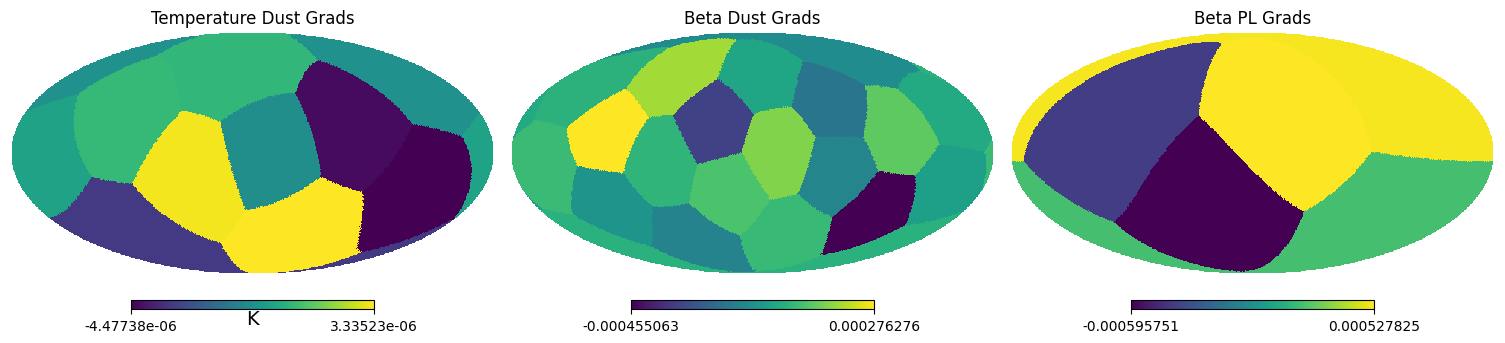

In [17]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

# Create maps for each parameter based on patches and their assigned values
temp_dust_map = grads['temp_dust'][temp_dust_patch_indices]
beta_dust_map = grads['beta_dust'][beta_dust_patch_indices]
beta_pl_map = grads['beta_pl'][beta_pl_patch_indices]

fig = plt.figure(figsize=(15, 5))

# Plot each map in a subplot
hp.mollview(temp_dust_map, title='Temperature Dust Grads', sub=(1, 3, 1), unit="K")
hp.mollview(beta_dust_map, title='Beta Dust Grads', sub=(1, 3, 2), unit="")
hp.mollview(beta_pl_map, title='Beta PL Grads', sub=(1, 3, 3), unit="")

# Display the combined plot
plt.show()


In [18]:
all_pixel_grads =  jax.grad(neg_log_prob)(all_pixels_param,all_patches,d)

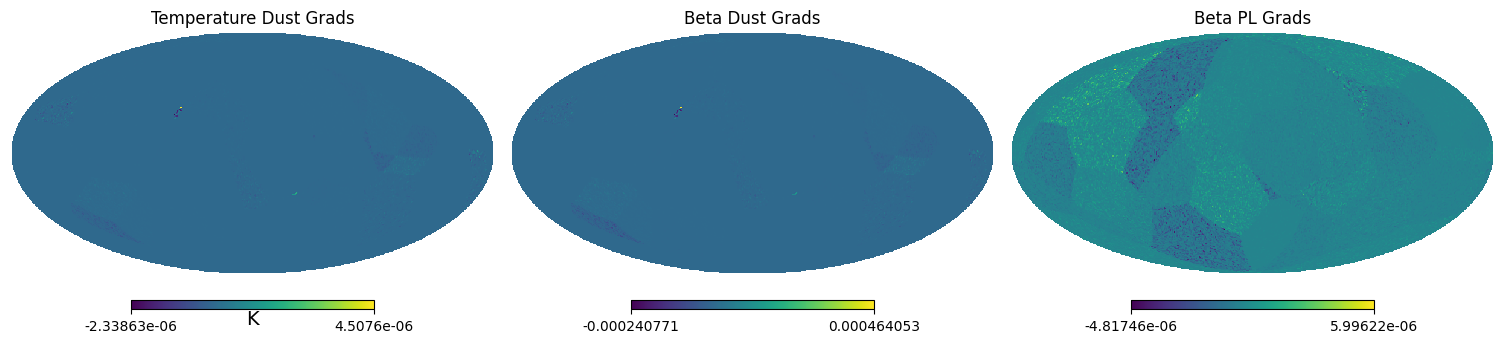

In [19]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

# Create maps for each parameter based on patches and their assigned values
temp_dust_map = all_pixel_grads['temp_dust']
beta_dust_map = all_pixel_grads['beta_dust']
beta_pl_map = all_pixel_grads['beta_pl']

fig = plt.figure(figsize=(15, 5))

# Plot each map in a subplot
hp.mollview(temp_dust_map, title='Temperature Dust Grads', sub=(1, 3, 1), unit="K")
hp.mollview(beta_dust_map, title='Beta Dust Grads', sub=(1, 3, 2), unit="")
hp.mollview(beta_pl_map, title='Beta PL Grads', sub=(1, 3, 3), unit="")

# Display the combined plot
plt.show()


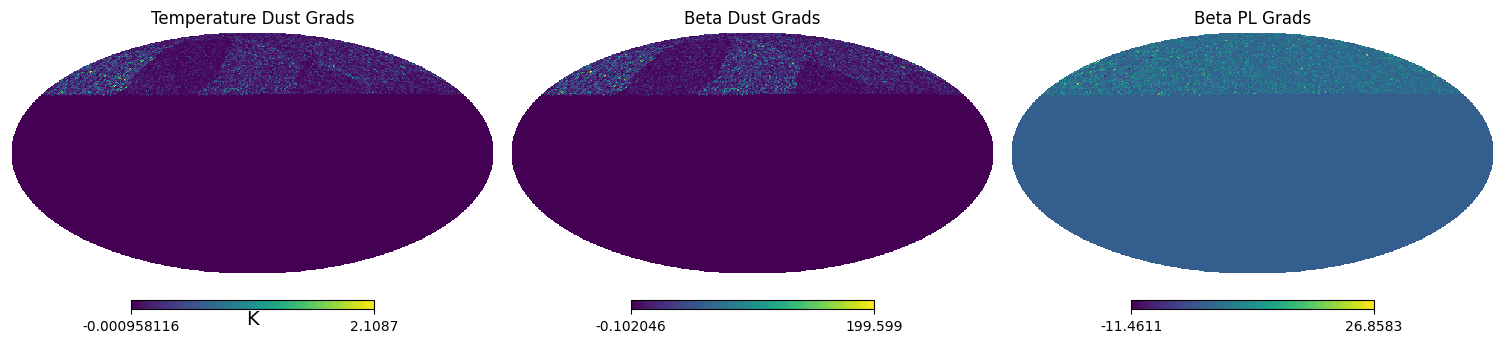

In [25]:
all_pixels_wrong = jax.tree.map(lambda x: x.at[:10000].add(1.), all_pixels_param)
all_pixels_wrong_grads =  jax.grad(neg_log_prob)(all_pixels_wrong,all_patches,d)

temp_dust_map = all_pixels_wrong_grads['temp_dust']
beta_dust_map = all_pixels_wrong_grads['beta_dust']
beta_pl_map = all_pixels_wrong_grads['beta_pl']

fig = plt.figure(figsize=(15, 5))

# Plot each map in a subplot
hp.mollview(temp_dust_map, title='Temperature Dust Grads', sub=(1, 3, 1), unit="K")
hp.mollview(beta_dust_map, title='Beta Dust Grads', sub=(1, 3, 2), unit="")
hp.mollview(beta_pl_map, title='Beta PL Grads', sub=(1, 3, 3), unit="")

# Display the combined plot
plt.show()

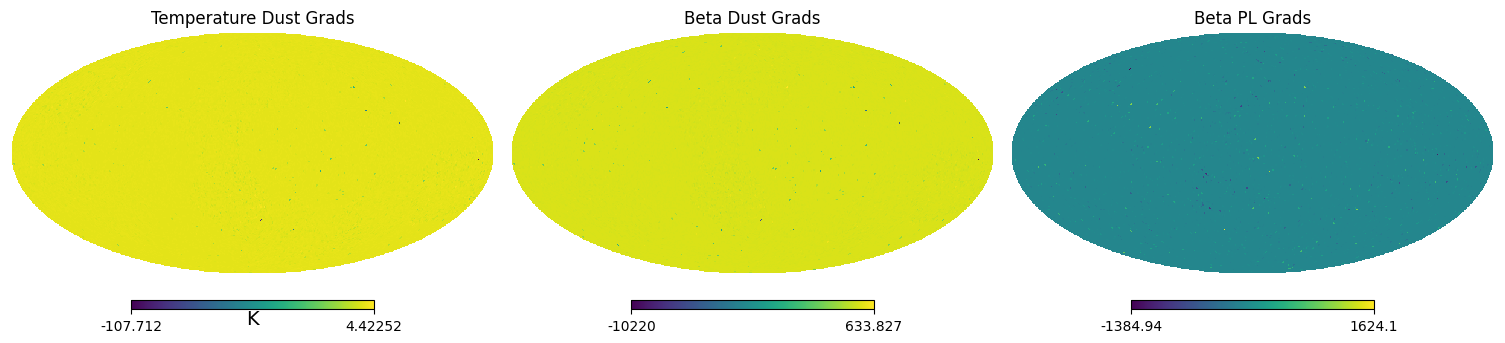

In [24]:
all_pixels_wrong = jax.tree.map(lambda x: x + jax.random.normal(jax.random.PRNGKey(3) , x.shape), all_pixels_param)
all_pixels_wrong_grads =  jax.grad(neg_log_prob)(all_pixels_wrong,all_patches,d)

temp_dust_map = all_pixels_wrong_grads['temp_dust']
beta_dust_map = all_pixels_wrong_grads['beta_dust']
beta_pl_map = all_pixels_wrong_grads['beta_pl']

fig = plt.figure(figsize=(15, 5))

# Plot each map in a subplot
hp.mollview(temp_dust_map, title='Temperature Dust Grads', sub=(1, 3, 1), unit="K")
hp.mollview(beta_dust_map, title='Beta Dust Grads', sub=(1, 3, 2), unit="")
hp.mollview(beta_pl_map, title='Beta PL Grads', sub=(1, 3, 3), unit="")

# Display the combined plot
plt.show()

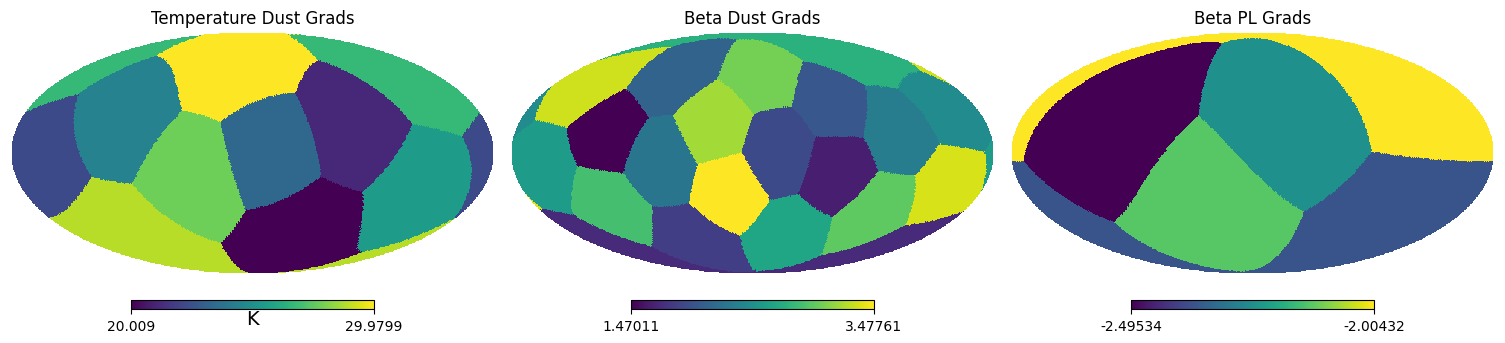

In [10]:
all_pixels_wrong = jax.tree.map(lambda x: x + jax.random.normal(jax.random.PRNGKey(3) , x.shape), all_pixels_param)

def average_grads(grads, patch_indices , patch_count):
    for patch_index in range(patch_count):
        grads = grads.at[np.where(patch_indices == patch_index)].set(jnp.mean(grads[np.where(patch_indices == patch_index)]))

    return grads

def uncluster(grads, patch_indices , patch_count):
    vals = jnp.zeros(patch_count)
    for patch_index in range(patch_count):
        vals = vals.at[patch_index].set(jnp.mean(grads[np.where(patch_indices == patch_index)]))

    return vals

temp_dust_grads = average_grads(all_pixels_wrong['temp_dust'], temp_dust_patch_indices, temp_dust_patches_count)
beta_dust_grads = average_grads(all_pixels_wrong['beta_dust'], beta_dust_patch_indices, beta_dust_patches_count)
beta_pl_grads = average_grads(all_pixels_wrong['beta_pl'], beta_pl_patch_indices, beta_pl_patches_count)

fig = plt.figure(figsize=(15, 5))

# Plot each map in a subplot
hp.mollview(temp_dust_grads, title='Temperature Dust Grads', sub=(1, 3, 1), unit="K")
hp.mollview(beta_dust_grads, title='Beta Dust Grads', sub=(1, 3, 2), unit="")
hp.mollview(beta_pl_grads, title='Beta PL Grads', sub=(1, 3, 3), unit="")

# Display the combined plot
plt.show()

In [29]:
wrong_all_params = jax.tree.map(lambda x: x + jax.random.normal(jax.random.PRNGKey(3)), all_pixels_param)

In [31]:
import jaxopt
from furax._base.config import ConfigState , Config
import lineax as lx

with Config(solver=lx.CG(rtol=1e-6, atol=1e-6, max_steps=6000)):

    solver = jaxopt.ScipyMinimize(fun=neg_log_prob,
                                method='TNC',
                                maxiter=1000,
                                jit=True,
                                tol=1e-10)
    %timeit  solver.run(best_params,patch_indices, d).params['beta_pl'].block_until_ready()

/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/jaxopt/_src/scipy_wrappers.py:343: OptimizeWarning: Unknown solver options: maxiter
  res = osp.optimize.minimize(scipy_fun, jnp_to_onp(init_params, self.dtype),
/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/jaxopt/_src/scipy_wrappers.py:343: OptimizeWarning: Unknown solver options: maxiter
  res = osp.optimize.minimize(scipy_fun, jnp_to_onp(init_params, self.dtype),


16.7 s ± 5.36 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [32]:
optimized_params = solver.run(best_params,patch_indices, d).params
print(f"Best params beta_dust \n{best_params['beta_dust']}")
print(f"Optimized params beta_dust \n{optimized_params['beta_dust']}")
print("-"*50)
print(f"Best params beta_pl \n{best_params['beta_pl']}")
print(f"Optimized params beta_pl \n{optimized_params['beta_pl']}")
print("-"*50)
print(f"Best params temp_dust \n{best_params['temp_dust']}")
print(f"Optimized params temp_dust \n{optimized_params['temp_dust']}")

Best params beta_dust 
[1.5        1.60526316 1.71052632 1.81578947 1.92105263 2.02631579
 2.13157895 2.23684211 2.34210526 2.44736842 2.55263158 2.65789474
 2.76315789 2.86842105 2.97368421 3.07894737 3.18421053 3.28947368
 3.39473684 3.5       ]
Optimized params beta_dust 
[1.50000023 1.60526304 1.71051917 1.81578928 1.92105327 2.02631443
 2.1315798  2.23684216 2.3421052  2.44736759 2.55263132 2.65789463
 2.76315862 2.86842138 2.97368314 3.07894698 3.18421242 3.28947295
 3.39473658 3.49999975]
--------------------------------------------------
Best params beta_pl 
[-2.5   -2.375 -2.25  -2.125 -2.   ]
Optimized params beta_pl 
[-2.49999992 -2.37499954 -2.25000005 -2.12499867 -2.00000102]
--------------------------------------------------
Best params temp_dust 
[20.         21.11111111 22.22222222 23.33333333 24.44444444 25.55555556
 26.66666667 27.77777778 28.88888889 30.        ]
Optimized params temp_dust 
[20.00001113 21.11113845 22.22222584 23.33332581 24.44445632 25.55555794
 26.

In [ ]:
with Config(solver=lx.CG(rtol=1e-2, atol=1e-2, max_steps=60000)):
    %time optimized_params = solver.run(wrong_all_params,all_patches, d).params
print(f"Best params beta_dust \n{best_params['beta_dust']}")
print(f"Optimized params beta_dust \n{uncluster(optimized_params['beta_dust'], beta_dust_patch_indices, beta_dust_patch_count)}")
print("-"*50)
print(f"Best params beta_pl \n{best_params['beta_pl']}")
print(f"Optimized params beta_pl \n{uncluster(optimized_params['beta_pl'], beta_pl_patch_indices, beta_pl_patch_count)}")
print("-"*50)
print(f"Best params temp_dust \n{best_params['temp_dust']}")
print(f"Optimized params temp_dust \n{uncluster(optimized_params['temp_dust'], temp_dust_patch_indices, temp_dust_patch_count)}")

/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/jaxopt/_src/scipy_wrappers.py:343: OptimizeWarning: Unknown solver options: maxiter
  res = osp.optimize.minimize(scipy_fun, jnp_to_onp(init_params, self.dtype),


In [14]:
optimized_params = solver.run(all_pixels_param,all_patches, d).params
print(f"Best params beta_dust \n{best_params['beta_dust']}")
print(f"Optimized params beta_dust \n{uncluster(optimized_params['beta_dust'], beta_dust_patch_indices, beta_dust_patch_count)}")
print("-"*50)
print(f"Best params beta_pl \n{best_params['beta_pl']}")
print(f"Optimized params beta_pl \n{uncluster(optimized_params['beta_pl'], beta_pl_patch_indices, beta_pl_patch_count)}")
print("-"*50)
print(f"Best params temp_dust \n{best_params['temp_dust']}")
print(f"Optimized params temp_dust \n{uncluster(optimized_params['temp_dust'], temp_dust_patch_indices, temp_dust_patch_count)}")

/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/jaxopt/_src/scipy_wrappers.py:343: OptimizeWarning: Unknown solver options: maxiter
  res = osp.optimize.minimize(scipy_fun, jnp_to_onp(init_params, self.dtype),


Best params beta_dust 
[1.5        1.60526316 1.71052632 1.81578947 1.92105263 2.02631579
 2.13157895 2.23684211 2.34210526 2.44736842 2.55263158 2.65789474
 2.76315789 2.86842105 2.97368421 3.07894737 3.18421053 3.28947368
 3.39473684 3.5       ]


NameError: name 'beta_dust_patch_count' is not defined

In [ ]:
params = {
    'temp_dust': best_params['temp_dust'] + jax.random.normal(jax.random.PRNGKey(1), (temp_dust_patch_count,)) * 3,
    'beta_dust': best_params['beta_dust'] + jax.random.normal(jax.random.PRNGKey(2), (beta_dust_patch_count,)) * 3,
    'beta_pl': best_params['beta_pl'] + jax.random.normal(jax.random.PRNGKey(3), (beta_pl_patch_count,)) * 3,
}

print(f"changed params")
print(params['temp_dust'])
print(params['beta_dust'])
print(params['beta_pl'])
print(f"best_params ")
print(best_params['temp_dust'])
print(best_params['beta_dust'])
print(best_params['beta_pl'])

optimized_params = solver.run(params,patch_indices, d).params
optimized_params
# Cannot inverse (max iter reached) 

changed params
[20.51807084 28.61747462]
[-3.55088677  3.85307254  2.78978273 -1.676114    1.20887232]
[-3.92516753  0.84338724  0.53891008 -2.09904508]
best_params 
[20. 30.]
[1.5 2.  2.5 3.  3.5]
[-2.5        -2.33333333 -2.16666667 -2.        ]


/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/jaxopt/_src/scipy_wrappers.py:343: OptimizeWarning: Unknown solver options: maxiter
  res = osp.optimize.minimize(scipy_fun, jnp_to_onp(init_params, self.dtype),
jax.pure_callback failed
Traceback (most recent call last):
  File "/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/jax/_src/callback.py", line 94, in pure_callback_impl
    return tree_util.tree_map(np.asarray, callback(*args))
  File "/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/jax/_src/callback.py", line 71, in __call__
    return tree_util.tree_leaves(self.callback_func(*args, **kwargs))
  File "/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/equinox/_errors.py", line 89, in raises
    raise _EquinoxRuntimeError(
equinox._errors._EquinoxRuntimeError: The maximum number of solver steps was reached. Try increasing `max_steps`.


--------------------
An error occurred during the runtime of your JAX program! Unfortunatel

XlaRuntimeError: INTERNAL: CustomCall failed: CpuCallback error: Traceback (most recent call last):
  File "/home/wassim/micromamba/envs/cmb/lib/python3.10/runpy.py", line 196, in _run_module_as_main
  File "/home/wassim/micromamba/envs/cmb/lib/python3.10/runpy.py", line 86, in _run_code
  File "/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
  File "/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance
  File "/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/ipykernel/kernelapp.py", line 739, in start
  File "/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/tornado/platform/asyncio.py", line 205, in start
  File "/home/wassim/micromamba/envs/cmb/lib/python3.10/asyncio/base_events.py", line 600, in run_forever
  File "/home/wassim/micromamba/envs/cmb/lib/python3.10/asyncio/base_events.py", line 1896, in _run_once
  File "/home/wass

In [ ]:
from furax.optimizers._optax import optimise , newton_cg
import optax
import optax.tree_utils as otu

solver = optax.lbfgs()

final_params, final_state = optimise(
    params,
    neg_log_prob,
    solver,
    max_iter=10,
    tol=1e-2,
    patch_indices=patch_indices,
    d=d,
)

print(f"Final parameters: {final_params}, number of evaluations: {otu.tree_get(final_state, 'count')}")
print(f"Initial Value: {neg_log_prob(final_params ,patch_indices=patch_indices, d=d)}")   


In [ ]:
# Define the Ray Tune Objective Function

params = {
    'temp_dust': best_params['temp_dust'] + jax.random.normal(jax.random.PRNGKey(1), (temp_dust_patches_count,)) ,
    'beta_dust': best_params['beta_dust'] + jax.random.normal(jax.random.PRNGKey(2), (beta_dust_patches_count,)) ,
    'beta_pl': best_params['beta_pl'] + jax.random.normal(jax.random.PRNGKey(3), (beta_pl_patches_count,)) ,
}

def objective(config):
    """
    Objective function for Ray Tune.
    Config contains clustering counts (e.g., for temp_dust, beta_dust).
    """
    # Extract clustering counts
    temp_dust_patches_count = config["temp_dust_patches_count"]
    beta_dust_patches_count = config["beta_dust_patches_count"]
    beta_pl_patches_count = config["beta_pl_patches_count"]

    # Simulated HEALPix map (replace with your real map)
    to_cluster_map = np.ones(hp.nside2npix(64))  # Example, replace with real data

    # Create patch indices
    temp_dust_patch_indices = cluster_healpix_map(to_cluster_map, temp_dust_patches_count)
    beta_dust_patch_indices = cluster_healpix_map(to_cluster_map, beta_dust_patches_count)
    beta_pl_patch_indices = cluster_healpix_map(to_cluster_map, beta_pl_patches_count)

    # Combine all patch indices (example logic)
    patch_indices = np.vstack([
        temp_dust_patch_indices,
        beta_dust_patch_indices,
        beta_pl_patch_indices,
    ])

    # Initialize solver
    solver = optax.lbfgs()

    # Define initial parameters and data (replace with actual logic)
    params = np.random.rand(10)  # Example
    d = None  # Placeholder for additional data

    # Optimize parameters
    final_params, final_state = optimise(
        params,
        neg_log_prob,
        solver,
        max_iter=10,
        tol=1e-2,
        patch_indices=patch_indices,
        d=d,
    )

    # Return score (e.g., final negative log probability)
    score = neg_log_prob(final_params, patch_indices, d)
    return {"score": score}

# Ray Tune Search Space
search_space = {
    "temp_dust_patches_count": tune.grid_search([5, 10, 20]),
    "beta_dust_patches_count": tune.grid_search([10, 20, 30]),
    "beta_pl_patches_count": tune.grid_search([2, 5, 10]),
}

# Run Ray Tune
tuner = tune.Tuner(objective, param_space=search_space)
results = tuner.fit()

# Get Best Result
best_result = results.get_best_result(metric="score", mode="min")
print(f"Best configuration: {best_result.config}")
print(f"Best score: {best_result.metrics['score']}")


In [ ]:
import numpyro
import numpyro.distributions as dist
import jax
import jax.numpy as jnp
from numpyro.infer import MCMC, NUTS
from numpyro import plate
from furax.landscapes import HealpixLandscape
invN = HomothetyOperator(jnp.ones(1), _in_structure=d.structure)  # Assuming this is already set
in_structure = HealpixLandscape(nside, stokes_type).structure
# Function to calculate the Gaussian log-likelihood based on `d` and mixing matrix `A`
@jax.jit
def log_likelihood(params,patch_indices, d):
    # Create the mixing matrix operator `A` based on `params` without needing `sky`
    A = make_mixing_matrix_operator(params, patch_indices , in_structure=in_structure)  # Pass shape of `d` to `make_mixing_matrix_operator`
    
    # Project data using `A` and noise inverse `invN`
    x = (A.T @ invN)(d)
    l = jax.tree.map(lambda a, b: a @ b, x, (A.T @ invN @ A).I(x))  # Computes likelihood term
    summed_likelihood = jax.tree.reduce(operator.add, l)   # Summing over components
    
    return summed_likelihood  # Positive log-likelihood value

# Define the NumPyro model
def model(patch_indices,d):
    # Define priors for spectral parameters
    #nb_patch = numpyro.sample("nb_patch", dist.Categorical(jnp.arange(5 , 30 , 5)))
    with plate("temp_dust_patches", temp_dust_patch_count):
        temp_dust = numpyro.sample("temp_dust", dist.Uniform(15., 50.))
    with plate("beta_dust_patches", beta_dust_patch_count):
        beta_dust = numpyro.sample("beta_dust", dist.Uniform(1.0, 3.0))
    with plate("beta_pl_patches", beta_pl_patch_count):
        beta_pl = numpyro.sample("beta_pl", dist.Uniform(-6.0, -1.0))

    # Pack parameters to use in the likelihood function
    params = {
        'temp_dust': temp_dust,
        'beta_dust': beta_dust,
        'beta_pl': beta_pl
    }

    # Compute and add the log-likelihood to the model using numpyro.factor
    numpyro.factor("log_likelihood", log_likelihood(params,patch_indices , d))


In [16]:
# Run MCMC sampling with a reduced sample count for quick testing
rng_key = jax.random.PRNGKey(1)
kernel = NUTS(model)
mcmc = MCMC(kernel, num_warmup=500, num_samples=500)  # Adjust sample count for speed
mcmc.run(rng_key, patch_indices=patch_indices , d=d)
samples = mcmc.get_samples()

mcmc.print_summary()

NameError: name 'temp_dust_patch_count' is not defined

In [ ]:
# Updated NumPyro model with tighter priors
def model(patch_indices, d):
    # Define tighter priors for spectral parameters
    with plate("temp_dust_patches", temp_dust_patch_count):
        temp_dust = numpyro.sample("temp_dust", dist.Uniform(15., 25.))
    with plate("beta_dust_patches", beta_dust_patch_count):
        beta_dust = numpyro.sample("beta_dust", dist.Uniform(1.0, 2.0))
    with plate("beta_pl_patches", beta_pl_patch_count):
        beta_pl = numpyro.sample("beta_pl", dist.Uniform(-6.0, -1.0))

    # Pack parameters to use in the likelihood function
    params = {
        'temp_dust': temp_dust,
        'beta_dust': beta_dust,
        'beta_pl': beta_pl
    }

    # Compute and add the log-likelihood to the model using numpyro.factor
    numpyro.factor("log_likelihood", log_likelihood(params, patch_indices, d))

# Run MCMC sampling with tighter priors
rng_key = jax.random.PRNGKey(1)
kernel = NUTS(model)
mcmc = MCMC(kernel, num_warmup=500, num_samples=500)
mcmc.run(rng_key, patch_indices=patch_indices, d=d)
samples = mcmc.get_samples()
mcmc.print_summary()

In [ ]:
import arviz as az

inf_data = az.from_numpyro(mcmc)
az.summary(inf_data)

import corner

best_param = {'beta_dust': 1.54, 'beta_pl': -3.0, 'temp_dust': 20.0}
corner.corner(inf_data, truths=true_params)

In [ ]:
# Updated NumPyro model with tighter priors
def model(patch_indices, d):
    # Define tighter priors for spectral parameters
    with plate("temp_dust_patches", temp_dust_patch_count):
        temp_dust = numpyro.sample("temp_dust", dist.Uniform(15., 25.))
    with plate("beta_dust_patches", beta_dust_patch_count):
        beta_dust = numpyro.sample("beta_dust", dist.Uniform(1.0, 2.0))
    with plate("beta_pl_patches", beta_pl_patch_count):
        beta_pl = numpyro.sample("beta_pl", dist.Uniform(-6.0, -1.0))

    # Pack parameters to use in the likelihood function
    params = {
        'temp_dust': temp_dust,
        'beta_dust': beta_dust,
        'beta_pl': beta_pl
    }

    # Compute and add the log-likelihood to the model using numpyro.factor
    numpyro.factor("log_likelihood", log_likelihood(params, patch_indices, d))

# Run MCMC sampling with tighter priors
rng_key = jax.random.PRNGKey(1)
kernel = NUTS(model)
mcmc = MCMC(kernel, num_warmup=500, num_samples=500)
mcmc.run(rng_key, patch_indices=patch_indices, d=d)
samples = mcmc.get_samples()
mcmc.print_summary()